# Transformer architecture

This is a diagram you can find all over the internet, illustrating the transformer architecture. Our job today is to understand the diagram and what all the parts do.

<img src="img/attention_research_1.png" width="500">

In [40]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from lark import Lark
from tqdm.notebook import tqdm

<br><br><br><br><br>

## Sample problem

We'll do it in the context of a problem to solve: identifying and then generating valid sentences in a very simple language.

Below is the entire language, expressed as a [BNF grammar](https://en.wikipedia.org/wiki/Backus%E2%80%93Naur_form):

In [2]:
parser = Lark("""
    sentence:    subj    intrans
            |    subj    trans   obj
            | pp subj    intrans
            |    subj    intrans     pp
            |    subj pp intrans
            | pp subj    trans   obj
            |    subj    trans   obj pp
            |    subj pp trans   obj

    subj:      "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    obj:       "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    pp:   prep "THE" place  | prep "A" place_cons  | prep "AN" place_vowel

    entity:       entity_cons | entity_vowel
    place:        place_cons | place_vowel

    entity_cons:  "CAT" | "MOUSE" | "ROBOT"
    entity_vowel: "ALLIGATOR" | "ANT"
    place_cons:   "HOUSE" | "YARD" | "STREET"
    place_vowel:  "AIRPORT" | "OCEAN"

    prep:         "IN" | "UNDER" | "ABOVE"
    intrans:      "SMILES" | "BURPS" | "SLEEPS" | "EXPLODES"
    trans:        "CHASES" | "EATS" | "LOVES" | "HATES"

    %ignore " "
""", start="sentence", parser="lalr", keep_all_tokens=True)

This parser does the task algorithmically (`LALR(1)`). We'll want to train a model to do the same task.

In [3]:
print(parser.parse("THE CAT SMILES").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    intrans: SMILES


In [4]:
print(parser.parse("THE CAT EATS A MOUSE IN THE STREET").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    trans: EATS
    obj
        A
        entity_cons: MOUSE
    pp
        prep: IN
        THE
        place
            place_cons: STREET


<br><br><br><br><br>

Data will be given to the model as lists of 8 tokens, using `<BLANK>` as filler at the end.

This `is_valid` function is a drop-in replacement for what we'll want our first model to do.

In [5]:
BLANK = "<BLANK>"

SEQUENCE_LENGTH = 8

def is_valid(tokens):
    # length must be SEQUENCE_LENGTH
    if len(tokens) != SEQUENCE_LENGTH:
        return False

    # all tokens after the first BLANK must be BLANK, allowing for no BLANKs by adding one
    if not all(x == BLANK for x in tokens[(tokens + [BLANK]).index(BLANK):]):
        return False

    try:
        # try to parse the string without BLANKs
        parser.parse(" ".join([x for x in tokens if x != BLANK]))
        return True
    except Exception:
        return False

In [6]:
is_valid(["THE", "CAT", "SMILES", BLANK, BLANK, BLANK, BLANK, BLANK])

True

In [7]:
is_valid(["THE", "CAT", "EATS", "A", "MOUSE", "IN", "THE", "STREET"])

True

In [8]:
is_valid(["THE", "CAT", "EATS", BLANK, BLANK, BLANK, BLANK, BLANK])

False

<br><br><br><br><br>

## Dataset for this sample problem

Random sentences labeled by validity, in which 50% are `ok` and 50% are `bad`.

In [9]:
train_df = pd.read_csv("data/train.csv",    nrows=20000)
valid_df = pd.read_csv("data/validate.csv", nrows=20000)
testy_df = pd.read_csv("data/test.csv",     nrows=20000)

In [10]:
train_df

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok
1,IN,A,HOUSE,AN,ANT,CHASES,A,MOUSE,ok
2,IN,THE,STREET,THE,ANT,CHASES,THE,ANT,ok
3,IN,MOUSE,YARD,A,ROBOT,A,LOVES,A,bad
4,IN,A,YARD,ANT,ALLIGATOR,CHASES,AN,AN,bad
...,...,...,...,...,...,...,...,...,...
19995,A,ROBOT,CHASES,THE,ANT,UNDER,AN,AIRPORT,ok
19996,UNDER,AN,OCEAN,AN,ANT,HATES,THE,ALLIGATOR,ok
19997,AIRPORT,THE,AIRPORT,CAT,ALLIGATOR,LOVES,A,MOUSE,bad
19998,THE,ALLIGATOR,LOVES,AN,ANT,UNDER,A,YARD,ok


<br><br><br><br><br>

One-hot encoding for the 25 tokens:

In [11]:
TOKEN_INDEX = {
    x: i for i, x in enumerate([
        "THE", "A", "AN",
        "CAT", "MOUSE", "ROBOT", "ALLIGATOR", "ANT",
        "HOUSE", "YARD", "STREET", "AIRPORT", "OCEAN",
        "IN", "UNDER", "ABOVE",
        "SMILES", "BURPS", "SLEEPS", "EXPLODES",
        "CHASES", "EATS", "LOVES", "HATES",
        BLANK
    ])
}
VOCABULARY_SIZE = len(TOKEN_INDEX)

def df_to_onehot(df):
    x = torch.zeros((len(df), SEQUENCE_LENGTH, VOCABULARY_SIZE))
    token_columns = [f"t{i}" for i in range(SEQUENCE_LENGTH)]
    indexes = df[token_columns].apply(lambda col: col.map(TOKEN_INDEX).values)
    
    for i, colname in enumerate(token_columns):
        x[torch.arange(len(df)), i, indexes[colname]] = 1

    y = torch.tensor((df["label"] == "ok").astype(int).values, dtype=torch.long)

    return x, y

train_x, train_y = df_to_onehot(train_df)
valid_x, valid_y = df_to_onehot(valid_df)
testy_x, testy_y = df_to_onehot(testy_df)

<br><br><br><br><br>

Look at the first one in the training data:

In [12]:
train_df.iloc[:1]

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok


In [13]:
print(" " + " ".join(f"{x[:4]:4s}" for x in TOKEN_INDEX))
for i in range(SEQUENCE_LENGTH):
    print(str(train_x[0, i].tolist()).replace("0.0", "   "))

 THE  A    AN   CAT  MOUS ROBO ALLI ANT  HOUS YARD STRE AIRP OCEA IN   UNDE ABOV SMIL BURP SLEE EXPL CHAS EATS LOVE HATE <BLA
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,   

<br><br><br><br><br>

## Old-fashioned neural network

For each data row, we have 8 tokens, and each token is represented by a 25-dimensional one-hot vector.

For an old-fashioned, fully-connected neural network, just flatten it to a 8×25 = 200-dimensional input vector.

In [14]:
train_flat_x = train_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
valid_flat_x = valid_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
testy_flat_x = testy_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)

In [17]:
train_x.shape

torch.Size([20000, 8, 25])

In [16]:
train_flat_x.shape

torch.Size([20000, 200])

<br><br><br><br><br>

The model has a hidden layer of length 128 and then a two-class decision space.

In [41]:
HIDDEN_LAYER = 128

model_mlp = nn.Sequential(
    nn.Linear(SEQUENCE_LENGTH * VOCABULARY_SIZE, HIDDEN_LAYER),
    nn.ReLU(),
    nn.Linear(HIDDEN_LAYER, 2),
)

# train it!
loader = DataLoader(TensorDataset(train_flat_x, train_y), batch_size=256)
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=5e-4)
loss_fn = nn.CrossEntropyLoss()
best_loss, wait = np.inf, 0

train_losses, valid_losses = [], []
for epoch in tqdm(range(50)):
    model_mlp.train()  # tell PyTorch we're in "training mode"

    train_loss = 0
    for batch_x, batch_y in loader:
        # compute the loss for a batch of model predictions and targets
        loss = loss_fn(model_mlp(batch_x), batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(batch_x)
    train_loss /= len(train_flat_x)
    train_losses.append(train_loss)

    model_mlp.eval()  # tell PyTorch we're in "evaluation mode"

    with torch.no_grad():  # focus only on values, not derivatives
        valid_loss = loss_fn(model_mlp(valid_flat_x), valid_y).item()
    valid_losses.append(valid_loss)

  0%|          | 0/50 [00:00<?, ?it/s]

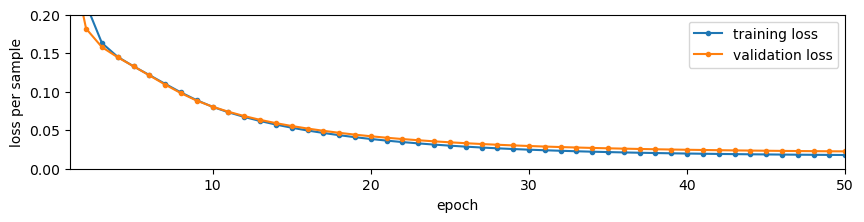

In [48]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.2)
ax.legend()

None